# 1. Environment Setup & Data Loading

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/win 11/Downloads/accident_prediction_india.csv")

In [4]:
df.head(10)

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection
5,Meghalaya,Unknown,2020,November,Tuesday,8:04,Serious,1,Truck,6,...,Village Road,Dry,Daylight,Police Checkpost,48,44,Male,Expired,Yes,Bridge
6,Sikkim,Unknown,2021,October,Monday,18:55,Fatal,2,Two-Wheeler,9,...,Urban Road,Under Construction,Dusk,Police Checkpost,111,48,Female,NaN,No,Straight Road
7,Himachal Pradesh,Unknown,2022,December,Wednesday,11:40,Minor,3,Truck,1,...,State Highway,Damaged,Dark,Police Checkpost,62,42,Female,Valid,No,Curve
8,Rajasthan,Jodhpur,2021,July,Saturday,8:26,Fatal,3,Truck,7,...,Urban Road,Damaged,Dawn,Signs,35,53,Male,Valid,No,Straight Road
9,Rajasthan,Jodhpur,2018,August,Saturday,2:01,Fatal,2,Car,3,...,State Highway,Under Construction,Dark,Signs,110,50,Female,NaN,Yes,Straight Road


# 2. Structural Inspection

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

In [6]:
df.describe()

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2020.530000,2.996000,5.066000,2.455333,74.940667,44.17700
std,1.683858,1.428285,3.214097,1.717650,26.765088,15.40286
min,2018.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2019.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2021.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2022.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2023.000000,5.000000,10.000000,5.000000,120.000000,70.00000


In [7]:
df.shape

(3000, 22)

3. Data Cleaning (The Preprocessing Phase)

In [8]:
# Missing Value Analysis:
df.isnull().sum()

State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64

In [9]:
# Duplicate Handling:
df.duplicated().sum()

np.int64(0)

In [10]:
# Data Type Correction:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
  df[col] = df[col].astype("category")
df.dtypes

State Name                     category
City Name                      category
Year                              int64
Month                          category
Day of Week                    category
Time of Day                    category
Accident Severity              category
Number of Vehicles Involved       int64
Vehicle Type Involved          category
Number of Casualties              int64
Number of Fatalities              int64
Weather Conditions             category
Road Type                      category
Road Condition                 category
Lighting Conditions            category
Traffic Control Presence       category
Speed Limit (km/h)                int64
Driver Age                        int64
Driver Gender                  category
Driver License Status          category
Alcohol Involvement            category
Accident Location Details      category
dtype: object

# 4. Univariate Analysis

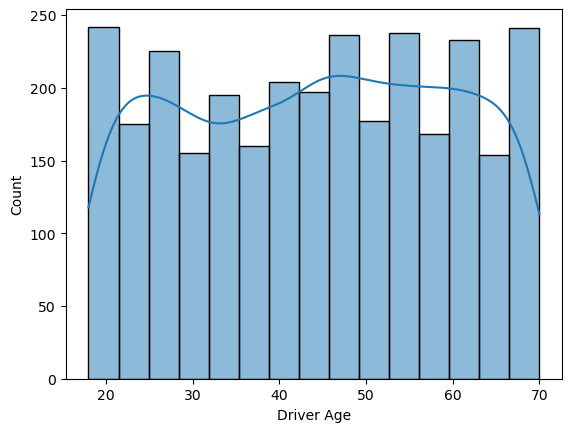

In [11]:
# Numerical:
sns.histplot(df['Driver Age'], kde=True)
plt.show()

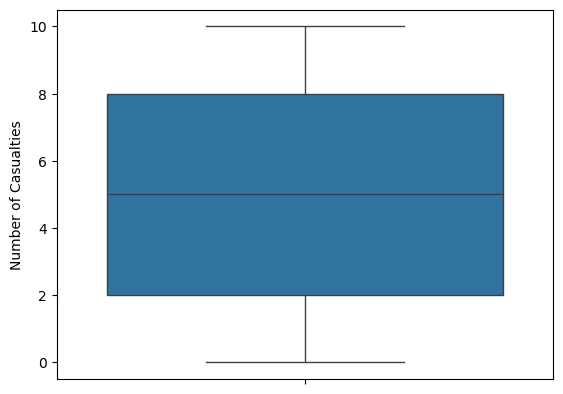

In [12]:
sns.boxplot(df['Number of Casualties'])
plt.show()

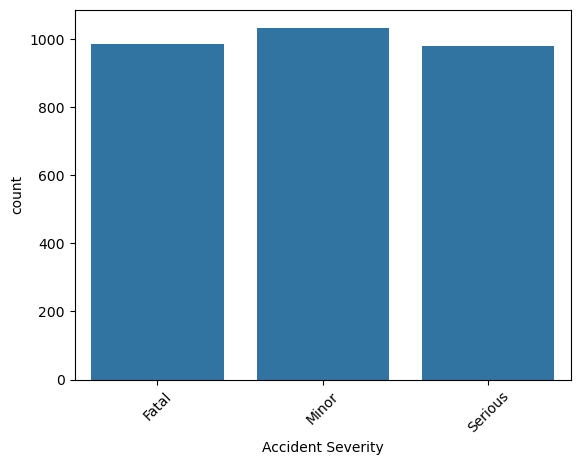

In [13]:
# Categorical:
sns.countplot(x="Accident Severity", data=df)
plt.xticks(rotation=45)
plt.show()

In [14]:
df['Weather Conditions'].value_counts()

Weather Conditions
Rainy     631
Stormy    611
Hazy      608
Foggy     576
Clear     574
Name: count, dtype: int64

# 5. Bivariate & Multivariate Analysis

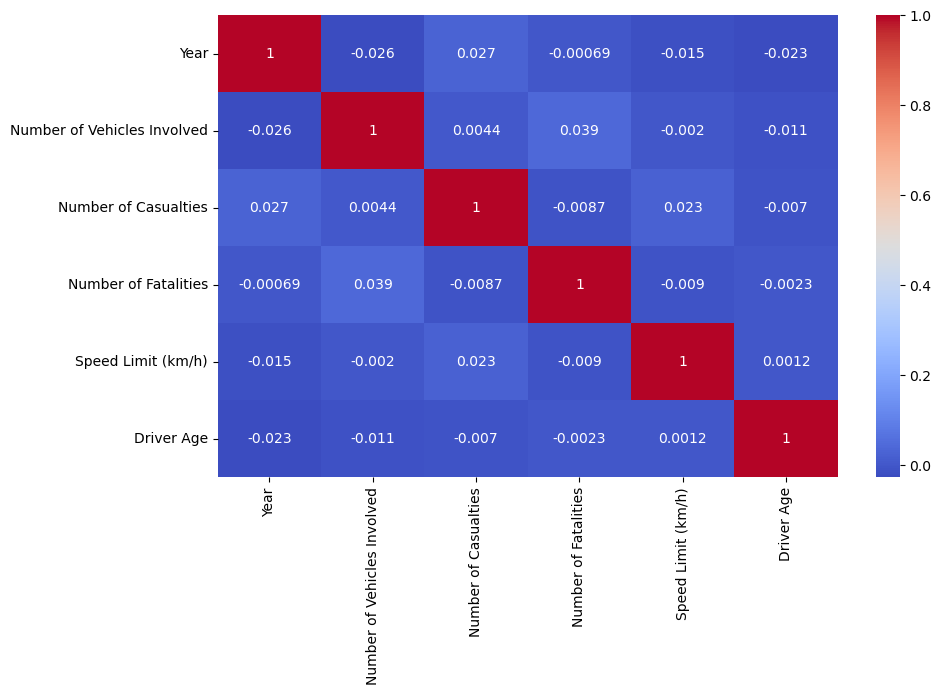

In [15]:
# Correlation Matrix:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True, cmap='coolwarm')
plt.show()

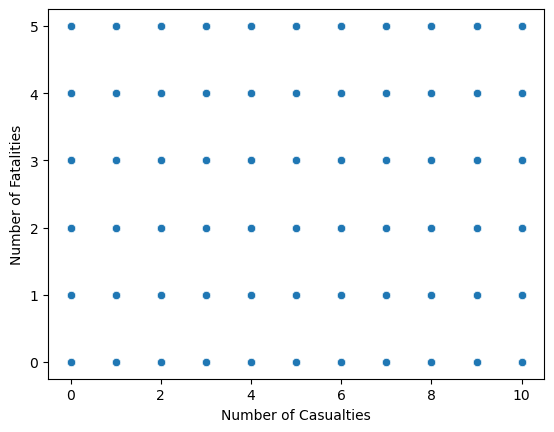

In [16]:
# Scatter Plots:
sns.scatterplot(data=df, x='Number of Casualties', y = 'Number of Fatalities')
plt.show()

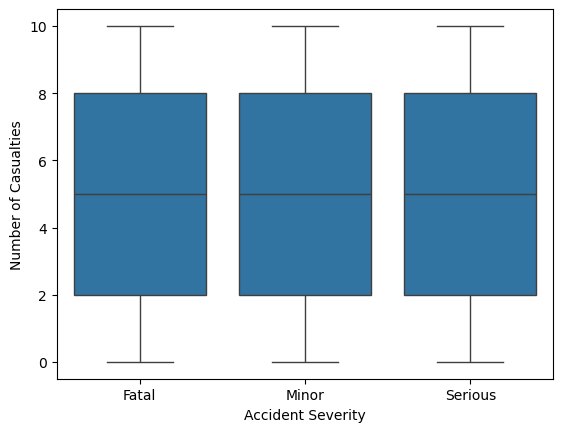

In [17]:
# Box Plots (Grouped):
sns.boxplot(data=df, x='Accident Severity', y='Number of Casualties')
plt.show()

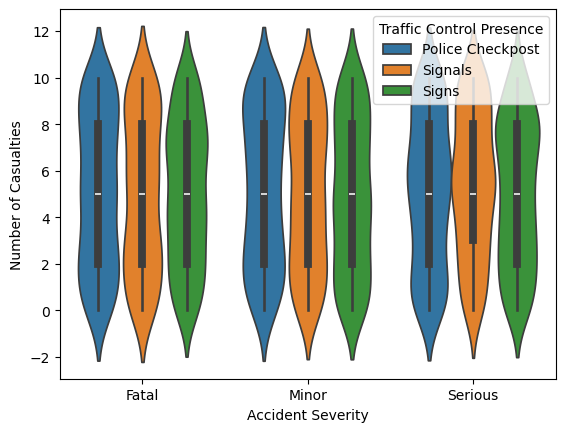

In [18]:
# Violin plot:
sns.violinplot(data=df, x='Accident Severity', y='Number of Casualties',hue='Traffic Control Presence')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 69.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 65.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.0% of the points

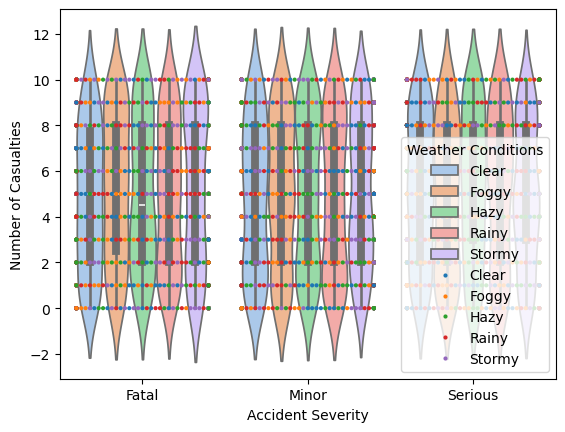

In [19]:
sns.violinplot(
    data=df,
    x='Accident Severity',
    y='Number of Casualties',
    hue='Weather Conditions',
    palette='pastel'
)

sns.swarmplot(
    data=df,
    x='Accident Severity',
    y='Number of Casualties',
    hue='Weather Conditions',
    size=3
)

plt.show()

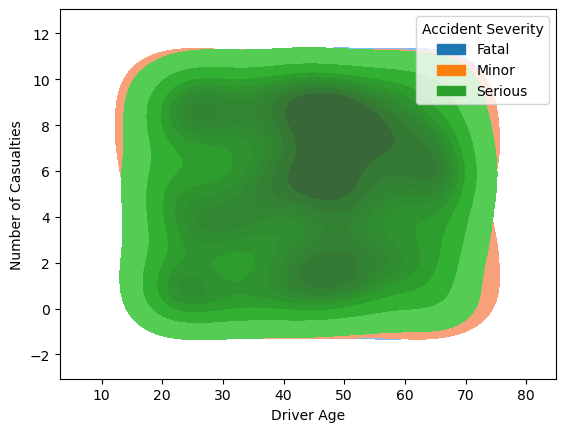

In [20]:
sns.kdeplot(data=df, x='Driver Age', y='Number of Casualties', hue='Accident Severity', fill=True)
plt.show()


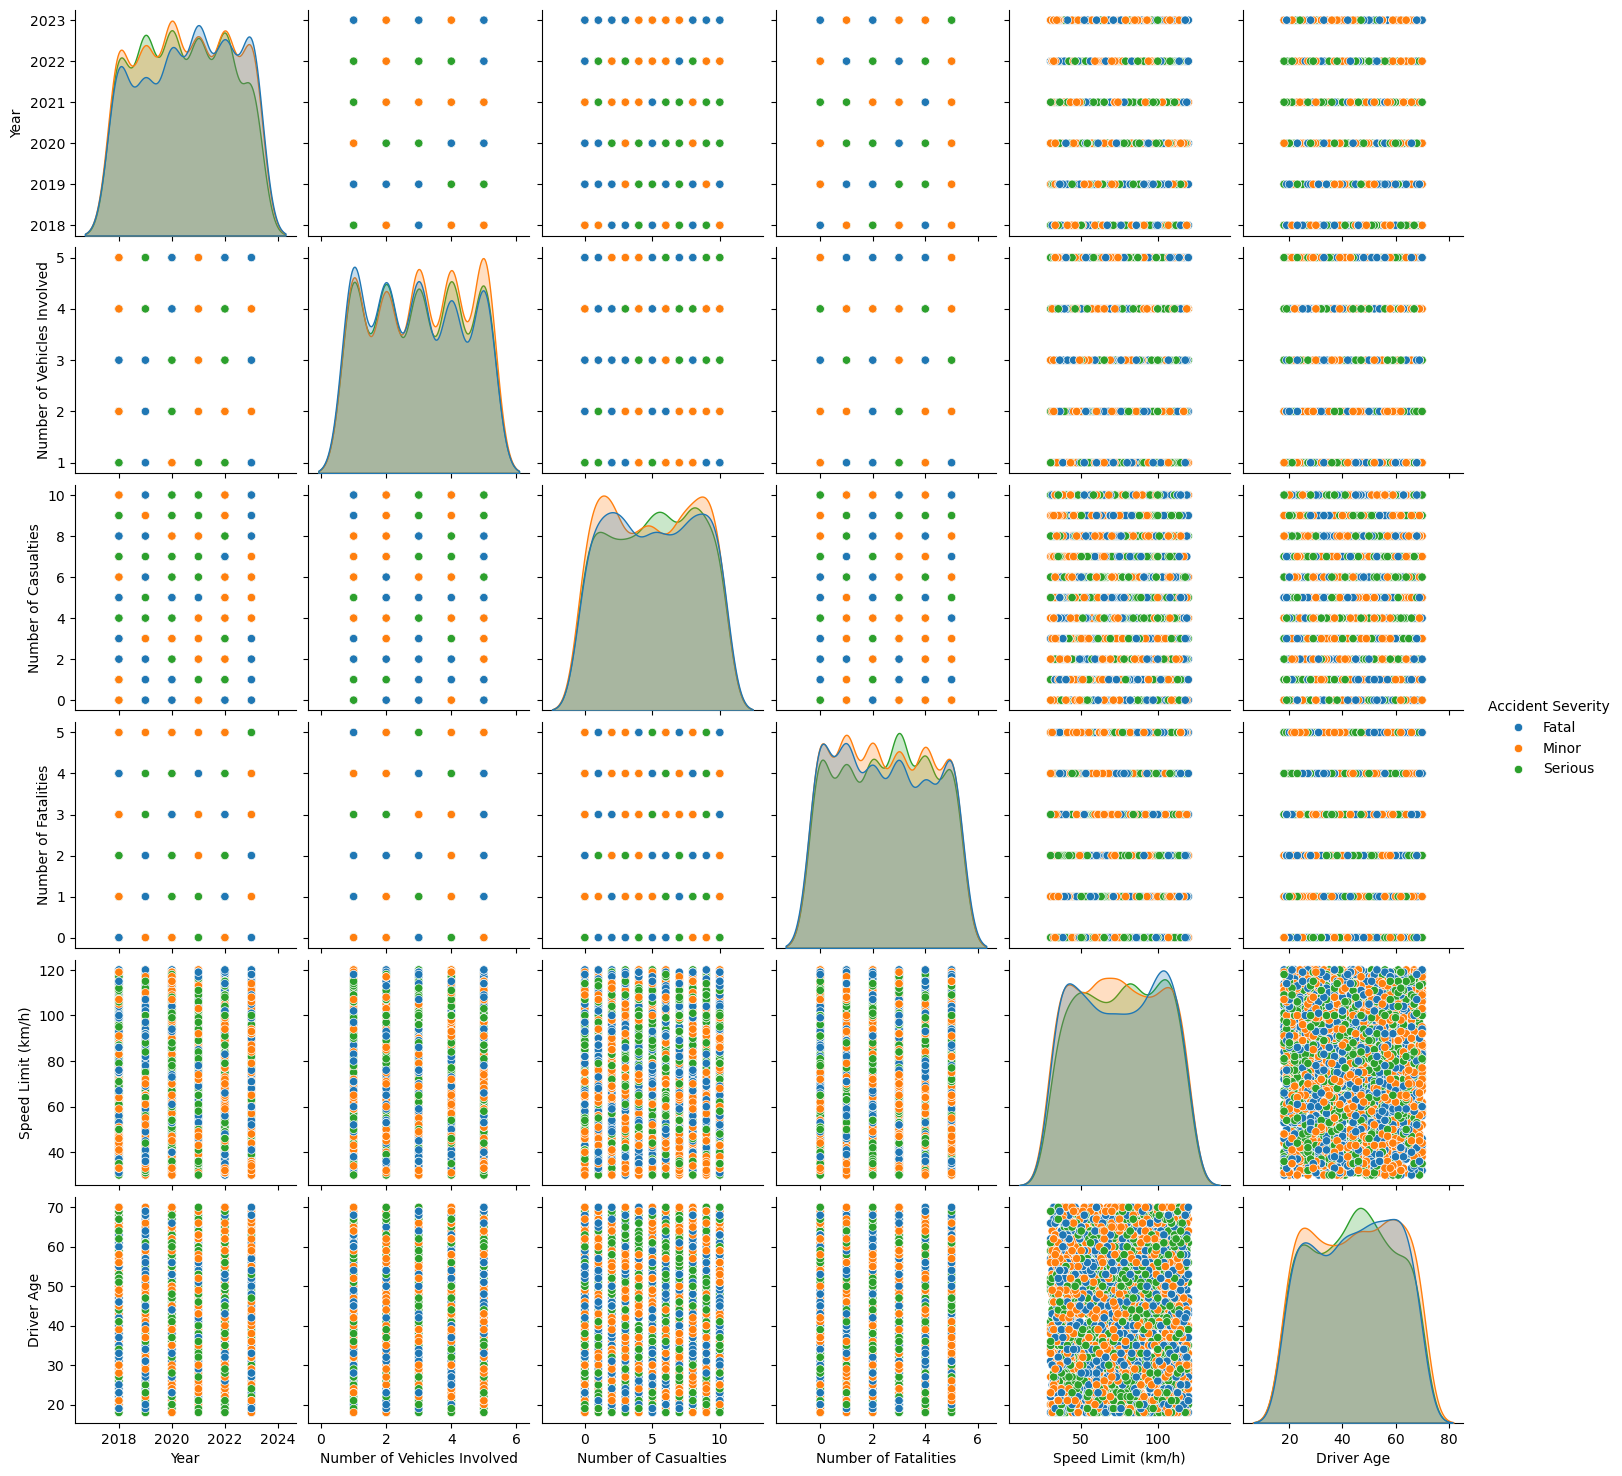

In [22]:
# pair plot:
sns.pairplot(df, hue='Accident Severity')
plt.show()